# Cricket Analytics and Tournament Intelligence System

## Project Objective

This project analyzes IPL player and team performances using Python, Pandas, and Matplotlib.

The project includes:

- Data Cleaning
- Batting Analysis
- Bowling Analysis
- Team Analysis
- Statistical Analysis
- Player Performance Index (PPI)
- Data Visualization

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import random

# Step 1: Create IPL Dataset

In this section, we generate a dataset containing 200 IPL player performances.

In [9]:
teams = [
    "CSK", "MI", "RCB", "KKR",
    "SRH", "RR", "DC", "PBKS",
    "GT", "LSG"
]

venues = [
    "Wankhede Stadium",
    "M. Chinnaswamy Stadium",
    "Eden Gardens",
    "Narendra Modi Stadium",
    "MA Chidambaram Stadium",
    "Arun Jaitley Stadium",
    "Rajiv Gandhi Stadium",
    "Sawai Mansingh Stadium"
]

players = [
    ("Virat Kohli", "RCB", "Batter"),
    ("Faf du Plessis", "RCB", "Batter"),
    ("Glenn Maxwell", "RCB", "All-Rounder"),
    ("Mohammed Siraj", "RCB", "Bowler"),

    ("MS Dhoni", "CSK", "Wicketkeeper"),
    ("Ruturaj Gaikwad", "CSK", "Batter"),
    ("Ravindra Jadeja", "CSK", "All-Rounder"),
    ("Deepak Chahar", "CSK", "Bowler"),

    ("Rohit Sharma", "MI", "Batter"),
    ("Suryakumar Yadav", "MI", "Batter"),
    ("Hardik Pandya", "MI", "All-Rounder"),
    ("Jasprit Bumrah", "MI", "Bowler"),

    ("Shubman Gill", "GT", "Batter"),
    ("Rashid Khan", "GT", "Bowler"),

    ("KL Rahul", "LSG", "Wicketkeeper"),
    ("Nicholas Pooran", "LSG", "Batter"),

    ("Sanju Samson", "RR", "Wicketkeeper"),
    ("Jos Buttler", "RR", "Batter"),

    ("David Warner", "DC", "Batter"),
    ("Axar Patel", "DC", "All-Rounder"),

    ("Shikhar Dhawan", "PBKS", "Batter"),
    ("Arshdeep Singh", "PBKS", "Bowler"),

    ("Pat Cummins", "SRH", "Bowler"),
    ("Nitish Kumar Reddy", "SRH", "All-Rounder"),

    ("Andre Russell", "KKR", "All-Rounder"),
    ("Sunil Narine", "KKR", "All-Rounder")
]

data = []
match_id = 1001

for i in range(200):

    player_name, team, role = players[i % len(players)]

    opponent = random.choice(teams)
    while opponent == team:
        opponent = random.choice(teams)

    date = f"2024-04-{random.randint(1,30):02d}"
    venue = random.choice(venues)

    if role == "Batter":
        runs = random.randint(0, 100)
        balls = random.randint(max(1, runs // 2), max(runs, 1) + 20)
        overs = 0
        wickets = 0
        runs_conceded = 0
        economy = 0

    elif role == "Bowler":
        runs = random.randint(0, 30)
        balls = random.randint(1, 25)
        overs = random.choice([2, 3, 4])
        wickets = random.randint(0, 5)
        runs_conceded = random.randint(15, 45)
        economy = round(runs_conceded / overs, 2)

    elif role == "All-Rounder":
        runs = random.randint(0, 80)
        balls = random.randint(max(1, runs // 2), max(runs, 1) + 15)
        overs = random.choice([1, 2, 3, 4])
        wickets = random.randint(0, 4)
        runs_conceded = random.randint(10, 40)
        economy = round(runs_conceded / overs, 2)

    else:
        runs = random.randint(0, 70)
        balls = random.randint(max(1, runs // 2), max(runs, 1) + 20)
        overs = 0
        wickets = 0
        runs_conceded = 0
        economy = 0

    
    max_fours = min(runs // 4, 10)
    fours = random.randint(0, max_fours)

    remaining = max(0, runs - (fours * 4))
    max_sixes = min(remaining // 6, 6)
    sixes = random.randint(0, max_sixes)

    strike_rate = round((runs / balls) * 100, 2)

    catches = random.randint(0, 3)

    match_result = random.choice(["Win", "Loss"])

    data.append({
        "Match_ID": match_id,
        "Date": date,
        "Team": team,
        "Opponent": opponent,
        "Venue": venue,
        "Player": player_name,
        "Role": role,
        "Runs": runs,
        "Balls_Faced": balls,
        "Fours": fours,
        "Sixes": sixes,
        "Strike_Rate": strike_rate,
        "Overs_Bowled": overs,
        "Wickets": wickets,
        "Runs_Conceded": runs_conceded,
        "Economy": economy,
        "Catches": catches,
        "Match_Result": match_result
    })

    if (i + 1) % 10 == 0:
        match_id += 1


df = pd.DataFrame(data)

df.to_csv("ipl_tournament_data.csv", index=False)

print("✅ CSV file created successfully!")

✅ CSV file created successfully!


# Step 2: Load Dataset

Read the CSV file using Pandas.

In [10]:
df = pd.read_csv("ipl_tournament_data.csv")

print(df)

     Match_ID        Date Team Opponent                   Venue  \
0        1001  2024-04-15  RCB       GT        Wankhede Stadium   
1        1001  2024-04-23  RCB      KKR  MA Chidambaram Stadium   
2        1001  2024-04-11  RCB       MI  Sawai Mansingh Stadium   
3        1001  2024-04-29  RCB      SRH  M. Chinnaswamy Stadium   
4        1001  2024-04-29  CSK     PBKS  MA Chidambaram Stadium   
..        ...         ...  ...      ...                     ...   
195      1020  2024-04-09   GT      LSG    Arun Jaitley Stadium   
196      1020  2024-04-29  LSG     PBKS        Wankhede Stadium   
197      1020  2024-04-08  LSG       GT  MA Chidambaram Stadium   
198      1020  2024-04-29   RR       DC   Narendra Modi Stadium   
199      1020  2024-04-19   RR      SRH  M. Chinnaswamy Stadium   

              Player          Role  Runs  Balls_Faced  Fours  Sixes  \
0        Virat Kohli        Batter    88           72      4      0   
1     Faf du Plessis        Batter    27           16

# Step 4: Batting Analysis

This section calculates:

- Top Batsmen
- Batting Average
- Strike Rate
- Boundary Percentage

In [12]:
def top_batsmen(df):

    batsmen = df.groupby("Player")["Runs"].sum()

    batsmen = batsmen.sort_values(ascending=False)

    return batsmen.head(10)


print(top_batsmen(df))

Player
Ruturaj Gaikwad       509
Suryakumar Yadav      480
Nicholas Pooran       476
David Warner          446
Jos Buttler           439
Virat Kohli           435
Shubman Gill          425
Faf du Plessis        394
Nitish Kumar Reddy    347
Axar Patel            336
Name: Runs, dtype: int64


In [13]:
def batting_average(df):

    average = df.groupby("Player")["Runs"].mean()

    return average.sort_values(ascending=False)


print(batting_average(df))

Player
David Warner          63.714286
Ruturaj Gaikwad       63.625000
Suryakumar Yadav      60.000000
Nicholas Pooran       59.500000
Jos Buttler           54.875000
Virat Kohli           54.375000
Shubman Gill          53.125000
Nitish Kumar Reddy    49.571429
Faf du Plessis        49.250000
Axar Patel            48.000000
Shikhar Dhawan        46.000000
Glenn Maxwell         39.625000
Andre Russell         39.428571
KL Rahul              36.625000
Rohit Sharma          36.375000
Hardik Pandya         36.125000
MS Dhoni              36.125000
Sunil Narine          35.714286
Ravindra Jadeja       33.750000
Sanju Samson          25.625000
Rashid Khan           21.625000
Jasprit Bumrah        18.500000
Mohammed Siraj        16.250000
Deepak Chahar         14.625000
Arshdeep Singh        13.857143
Pat Cummins           13.142857
Name: Runs, dtype: float64


In [14]:
def strike_rate(df):

    strike = df.groupby("Player")["Strike_Rate"].mean()

    return strike.sort_values(ascending=False)


print(strike_rate(df))

Player
Arshdeep Singh        513.690000
Jasprit Bumrah        415.606250
Pat Cummins           182.664286
Mohammed Siraj        175.538750
Rashid Khan           145.378750
David Warner          128.767143
Faf du Plessis        126.288750
Nitish Kumar Reddy    119.325714
Axar Patel            119.198571
Suryakumar Yadav      112.976250
KL Rahul              110.042500
Nicholas Pooran       109.422500
Ruturaj Gaikwad       108.016250
Jos Buttler           104.293750
Shikhar Dhawan        103.815714
Virat Kohli           103.196250
Rohit Sharma          100.967500
Hardik Pandya         100.788750
MS Dhoni               99.186250
Shubman Gill           93.603750
Glenn Maxwell          92.438750
Sunil Narine           92.145714
Andre Russell          90.848571
Ravindra Jadeja        83.146250
Sanju Samson           80.307500
Deepak Chahar          80.137500
Name: Strike_Rate, dtype: float64


In [16]:
def boundary_percentage(df):

    df["Boundary_Percentage"] = (

        (4*df["Fours"] + 6*df["Sixes"])

        /

        df["Runs"].replace(0,1)

    )*100

    return df[["Player","Boundary_Percentage"]]


print(boundary_percentage(df))

              Player  Boundary_Percentage
0        Virat Kohli            18.181818
1     Faf du Plessis            88.888889
2      Glenn Maxwell            80.000000
3     Mohammed Siraj            70.588235
4           MS Dhoni            86.956522
..               ...                  ...
195      Rashid Khan            46.153846
196         KL Rahul            78.260870
197  Nicholas Pooran            64.367816
198     Sanju Samson            59.259259
199      Jos Buttler            90.000000

[200 rows x 2 columns]


# Step 5: Bowling Analysis

This section calculates:

- Top Bowlers
- Economy Rate
- Bowling Average

In [17]:
def top_bowlers(df):

    bowlers = df.groupby("Player")["Wickets"].sum()

    bowlers = bowlers.sort_values(ascending=False)

    return bowlers.head(10)


print(top_bowlers(df))

Player
Jasprit Bumrah     21
Ravindra Jadeja    20
Mohammed Siraj     19
Rashid Khan        18
Andre Russell      16
Sunil Narine       15
Glenn Maxwell      15
Hardik Pandya      15
Deepak Chahar      15
Pat Cummins        15
Name: Wickets, dtype: int64


In [18]:
def economy(df):

    eco = df.groupby("Player")["Economy"].mean()

    return eco.sort_values()


print(economy(df))

Player
Virat Kohli            0.000000
Nicholas Pooran        0.000000
Suryakumar Yadav       0.000000
MS Dhoni               0.000000
KL Rahul               0.000000
Jos Buttler            0.000000
Sanju Samson           0.000000
Ruturaj Gaikwad        0.000000
Faf du Plessis         0.000000
Shubman Gill           0.000000
David Warner           0.000000
Shikhar Dhawan         0.000000
Rohit Sharma           0.000000
Pat Cummins            8.000000
Axar Patel             8.667143
Sunil Narine          10.142857
Nitish Kumar Reddy    10.631429
Mohammed Siraj        10.855000
Deepak Chahar         10.968750
Glenn Maxwell         11.031250
Arshdeep Singh        12.370000
Rashid Khan           12.750000
Jasprit Bumrah        12.843750
Hardik Pandya         14.363750
Ravindra Jadeja       15.750000
Andre Russell         17.285714
Name: Economy, dtype: float64


In [20]:
def bowling_average(df):

    df["Bowling_Average"] = (

        df["Runs_Conceded"]

        /

        df["Wickets"].replace(0,1)

    )

    return df[["Player","Bowling_Average"]]


print(bowling_average(df))

              Player  Bowling_Average
0        Virat Kohli              0.0
1     Faf du Plessis              0.0
2      Glenn Maxwell             29.0
3     Mohammed Siraj             11.0
4           MS Dhoni              0.0
..               ...              ...
195      Rashid Khan             42.0
196         KL Rahul              0.0
197  Nicholas Pooran              0.0
198     Sanju Samson              0.0
199      Jos Buttler              0.0

[200 rows x 2 columns]


# Step 6: Team Analysis

This section compares all IPL teams based on:

- Runs
- Wickets
- Catches

In [21]:
def team_runs(df):

    runs = df.groupby("Team")["Runs"].sum()

    return runs.sort_values(ascending=False)


print(team_runs(df))

Team
RCB     1276
MI      1208
CSK     1185
DC       782
LSG      769
RR       644
GT       598
KKR      526
SRH      439
PBKS     419
Name: Runs, dtype: int64


In [22]:
def team_wickets(df):

    wickets = df.groupby("Team")["Wickets"].sum()

    return wickets.sort_values(ascending=False)

print(team_wickets(df))

Team
MI      36
CSK     35
RCB     34
KKR     31
SRH     29
GT      18
DC      14
PBKS    14
LSG      0
RR       0
Name: Wickets, dtype: int64


In [23]:
def team_catches(df):

    catches = df.groupby("Team")["Catches"].sum()

    return catches.sort_values(ascending=False)


print(team_catches(df))

Team
MI      49
CSK     46
RCB     43
RR      31
PBKS    24
KKR     22
LSG     22
GT      21
DC      20
SRH     18
Name: Catches, dtype: int64


# Step 7: Statistical Analysis

The following statistics are calculated:

- Mean
- Median
- Mode
- Variance
- Standard Deviation
- Minimum
- Maximum
- Correlation

In [24]:
print("Mean")

print(df["Runs"].mean())


print("Median")

print(df["Strike_Rate"].median())


print("Mode")

print(df["Runs"].mode())


print("Variance")

print(df["Runs"].var())


print("Standard Deviation")

print(df["Economy"].std())


print("Minimum")

print(df["Runs"].min())


print("Maximum")

print(df["Runs"].max())


print("Correlation")

print(df["Runs"].corr(df["Strike_Rate"]))

Mean
39.23
Median
100.675
Mode
0    30
Name: Runs, dtype: int64
Variance
787.7860301507537
Standard Deviation
8.1484720761551
Minimum
0
Maximum
100
Correlation
-0.004078694812669026


# Step 8: Player Performance Index

PPI Formula

PPI =
0.4 × Runs
+25 × Wickets
+5 × Catches
+0.1 × Strike Rate
−2 × Economy

Players are ranked using this score.

In [25]:
df["PPI"] = (

0.4*df["Runs"] + 25*df["Wickets"] + 5*df["Catches"] + 0.1*df["Strike_Rate"] - 2*df["Economy"]

)

ppi = df.groupby("Player")["PPI"].mean()

ppi = ppi.sort_values(ascending=False)

print(ppi)

Player
Jasprit Bumrah        96.398125
Arshdeep Singh        90.029000
Axar Patel            70.928429
Nitish Kumar Reddy    67.641143
Pat Cummins           66.809286
Mohammed Siraj        66.718875
Sunil Narine          64.643143
Ravindra Jadeja       60.939625
Rashid Khan           60.812875
Glenn Maxwell         58.656375
Andre Russell         55.284857
Hardik Pandya         52.676375
Deepak Chahar         47.551250
David Warner          45.505286
Jos Buttler           44.254375
Nicholas Pooran       44.117250
Ruturaj Gaikwad       41.251625
Suryakumar Yadav      40.297625
Virat Kohli           39.569625
Shikhar Dhawan        38.067286
Faf du Plessis        37.953875
Shubman Gill          36.860375
Rohit Sharma          32.771750
MS Dhoni              31.243625
KL Rahul              30.029250
Sanju Samson          25.780750
Name: PPI, dtype: float64


# Step 9: Data Visualization

Graphs included:

1. Top 10 Batsmen
2. Top 10 Bowlers
3. Runs vs Strike Rate
4. Team Performance

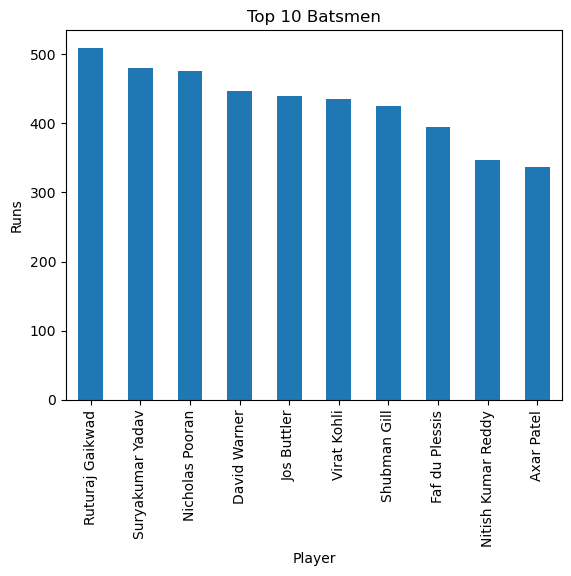

In [26]:
top = top_batsmen(df)

top.plot(kind="bar")

plt.title("Top 10 Batsmen")

plt.xlabel("Player")

plt.ylabel("Runs")

plt.show()

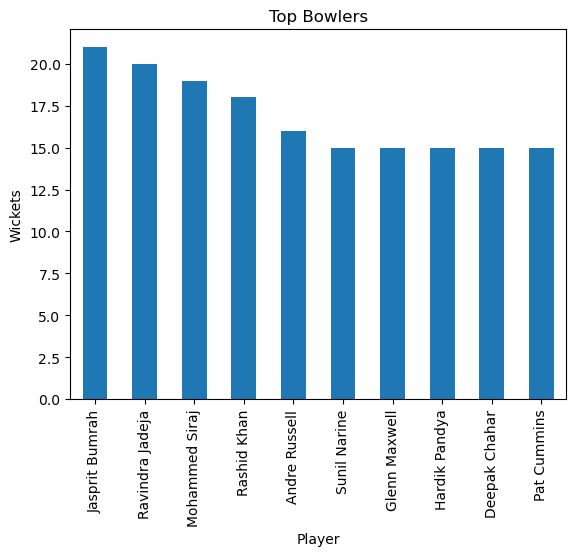

In [27]:
top = top_bowlers(df)

top.plot(kind="bar")

plt.title("Top Bowlers")

plt.xlabel("Player")

plt.ylabel("Wickets")

plt.show()

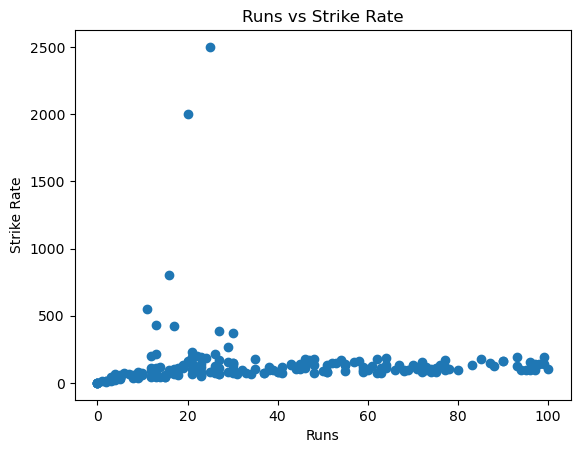

In [28]:
plt.scatter(df["Runs"],df["Strike_Rate"])

plt.xlabel("Runs")

plt.ylabel("Strike Rate")

plt.title("Runs vs Strike Rate")

plt.show()

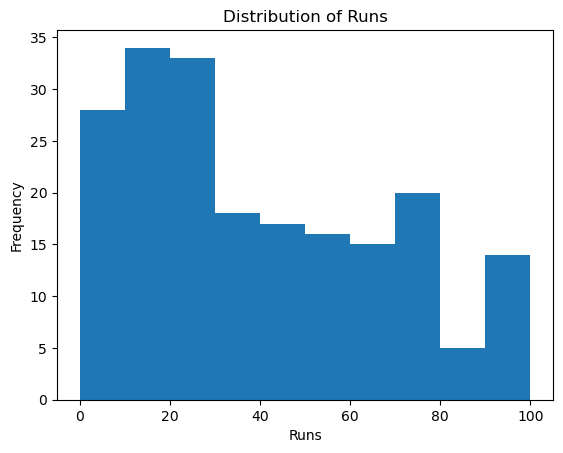

In [29]:
plt.hist(df["Runs"])

plt.title("Distribution of Runs")

plt.xlabel("Runs")

plt.ylabel("Frequency")

plt.show()

# Step 10: Save Results

The cleaned dataset and summary files are saved as CSV files.

In [30]:
summary = df.groupby("Player").agg({

"Runs":"sum",

"Wickets":"sum",

"Catches":"sum"

})

summary.to_csv("player_summary.csv")

print("Summary Saved Successfully")

Summary Saved Successfully
